# Tournament analysis 2 (260715): reward instead of score

Companion to `tournament_analysis_demo`, ranking the shortlisted models on **reward** rather than **player score**.

> **DATA NOTE.** The tournament was run with `build_260724_01_tournament`, which has the no-movement penalty-break absent (verified by decompile + behaviour): every step is penalised, not just non-rest actions. That is a *different* reward structure from what the models were trained under (`build_260715_01_social`, penalty-break **present**, resting free). So the tournament reward does **not** reflect the trained reward landscape.
>
> 
> Hold this notebook back until another tournament is run, using a build with the penalty-break clause in

- **score** = terminal outcome (winner 1.0 High / 0.4 Low, loser 0).
- **reward** (`trialRewards`) = score - step_penalty x (**all** episode steps). Resting is penalised too, and episode length is fixed by the predetermined trial sequence and symmetric between the two competitors, so the penalty is ~constant across models. Reward is therefore essentially **score minus a constant** and reorders nothing; losers get a negative reward.


In [1]:
import os
import io
import contextlib
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import globals
import parse_data.loading as loading
import parse_data.preprocess_sim as preprocess_sim

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

BASE = os.path.expanduser('~/Unity/Octagon/simulations/tournaments/260715')
STEP_PENALTY = 0.001                    # for reference; reward = score - STEP_PENALTY * action_steps

STRATEGY = {22: 'central', 20: 'central', 2: 'central',
            14: 'intermediate', 10: 'intermediate',
            36: 'peripheral', 15: 'peripheral', 26: 'peripheral'}
MODELS = sorted(STRATEGY)
STRAT_ORDER = ['central', 'intermediate', 'peripheral']
STRAT_PALETTE = {'central': '#4C72B0', 'intermediate': '#55A868', 'peripheral': '#DD8452'}

## Extraction and helpers

Same as the score notebook, but the trial-end rows also carry each agent's **reward** (`trialRewards`) alongside its score. Winner + walls from the trigger event, authoritative per-agent score/reward from the trial-end event, merged on `trialNum`.

In [2]:
def model_ids(folder):
    ''' Return (model_A, model_B) ints from a matchup folder name. Takes a folder like
        "260715_0022__vs__260715_0002". A drives agent 0 (P1), B drives agent 1 (P2). '''
    a, b = folder.split('__vs__')
    return int(a.split('_')[1]), int(b.split('_')[1])


def extract_matchup(folder, base=BASE):
    ''' Return a per-trial dataframe for one matchup. Takes a matchup folder name and the
        tournaments dir. Columns: the two models, winner, each model's score and reward, sep. '''
    d = os.path.join(base, folder)
    fn = next(f for f in os.listdir(d)
              if f.endswith('.json') and not f.startswith('._') and 'config' not in f)
    with contextlib.redirect_stdout(io.StringIO()):
        df = loading.loading_pipeline(d, fn)
        df = preprocess_sim.standard_preprocessing_sim(df)

    TN = globals.TRIAL_NUM
    trig = df[df['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION][
        [TN, globals.TRIGGER_CLIENT, globals.WALL_1, globals.WALL_2]].dropna(subset=[TN])
    te = df[df['eventDescription'] == globals.TRIAL_END][
        [TN, globals.PLAYER_0_TRIAL_SCORE, globals.PLAYER_1_TRIAL_SCORE,
         globals.PLAYER_0_TRIAL_REWARD, globals.PLAYER_1_TRIAL_REWARD]].dropna(subset=[TN])
    m = trig.merge(te, on=TN, how='inner')                # align the two streams by trial number

    a, b = model_ids(folder)
    w1 = m[globals.WALL_1].to_numpy(float); w2 = m[globals.WALL_2].to_numpy(float)
    dd = np.abs(w1 - w2) % 8
    return pd.DataFrame(dict(
        matchup=folder, model_A=a, model_B=b, trial_num=m[TN].to_numpy(float),
        winner_client=m[globals.TRIGGER_CLIENT].to_numpy(float),
        score_A=m[globals.PLAYER_0_TRIAL_SCORE].astype(float).to_numpy(),
        score_B=m[globals.PLAYER_1_TRIAL_SCORE].astype(float).to_numpy(),
        reward_A=m[globals.PLAYER_0_TRIAL_REWARD].astype(float).to_numpy(),
        reward_B=m[globals.PLAYER_1_TRIAL_REWARD].astype(float).to_numpy(),
        sep=np.minimum(dd, 8 - dd).astype(int)))


def fit_bradley_terry(wins, prior=0.5, n_iter=2000, tol=1e-10):
    ''' Return Bradley-Terry strengths from a wins matrix. Takes wins[i,j] = times i beat j.
        Wins are unaffected by score-vs-reward (same winner), so this matches the score notebook. '''
    W = wins.astype(float) + prior
    np.fill_diagonal(W, 0.0)
    n = W.shape[0]
    total_wins = W.sum(axis=1)
    games = W + W.T
    p = np.ones(n)
    for _ in range(n_iter):
        p_old = p.copy()
        for i in range(n):
            denom = np.sum([games[i, j] / (p[i] + p[j]) for j in range(n) if j != i])
            p[i] = total_wins[i] / denom if denom > 0 else p[i]
        p /= p.mean()
        if np.max(np.abs(p - p_old)) < tol:
            break
    return p

## Main pass — load every matchup

In [3]:
matchup_folders = sorted(d for d in os.listdir(BASE)
                         if '__vs__' in d and os.path.isdir(os.path.join(BASE, d)))
records, no_done = [], []
for folder in matchup_folders:
    if not os.path.exists(os.path.join(BASE, folder, 'DONE.txt')):
        no_done.append(folder)
    records.append(extract_matchup(folder))
    print(f"{folder} done", end='  ')
trials_df = pd.concat(records, ignore_index=True)
print(f"\n\nmatchups: {len(records)} / {len(matchup_folders)}   trials: {len(trials_df)}")
if no_done: print(f"MISSING DONE.txt: {no_done}")

# one row per model-perspective per trial, so both seat orders pool naturally
perspective = pd.concat([
    trials_df.assign(focus=trials_df.model_A, opp=trials_df.model_B, f_score=trials_df.score_A,
                     f_reward=trials_df.reward_A, f_win=(trials_df.winner_client == 0).astype(float)),
    trials_df.assign(focus=trials_df.model_B, opp=trials_df.model_A, f_score=trials_df.score_B,
                     f_reward=trials_df.reward_B, f_win=(trials_df.winner_client == 1).astype(float)),
], ignore_index=True)[['matchup', 'focus', 'opp', 'f_score', 'f_reward', 'f_win', 'sep']]
selfless = perspective[perspective.focus != perspective.opp]   # drop self-matchups for competitive stats

260715_0002__vs__260715_0002 done  

260715_0002__vs__260715_0010 done  

260715_0002__vs__260715_0014 done  

260715_0002__vs__260715_0015 done  

260715_0002__vs__260715_0020 done  

...

260715_0036__vs__260715_0015 done  

260715_0036__vs__260715_0020 done  

260715_0036__vs__260715_0022 done  

260715_0036__vs__260715_0026 done  

260715_0036__vs__260715_0036 done  

matchups: 64 / 64   trials: 22312


## Validation

Same fairness checks as the score notebook (nothing here depends on reward): self-matchups near 0.5, small mirror gaps.

In [4]:
pm = trials_df.groupby(['matchup', 'model_A', 'model_B']).agg(
    p1_win=('winner_client', lambda s: float(np.mean(s == 0)))).reset_index()
self_tbl = pm[pm.model_A == pm.model_B]
print(f"Self-matchup P1 win rate: mean {self_tbl.p1_win.mean():.3f}, "
      f"worst deviation from 0.5: {(self_tbl.p1_win - 0.5).abs().max():.3f}")
pmi = pm.set_index(['model_A', 'model_B'])
gaps = [abs(pmi.loc[(a, b), 'p1_win'] - (1 - pmi.loc[(b, a), 'p1_win'])) for a, b in combinations(MODELS, 2)]
print(f"Mirror consistency over {len(gaps)} pairs: mean gap {np.mean(gaps):.3f}, max {np.max(gaps):.3f}")
# reward sanity: losers pay penalty (reward can be < 0); winner-take-all still holds on score
print(f"reward range: [{trials_df[['reward_A','reward_B']].min().min():.3f}, "
      f"{trials_df[['reward_A','reward_B']].max().max():.3f}]  "
      f"(negative = moved and lost)")

Self-matchup P1 win rate: mean 0.525, worst deviation from 0.5: 0.067
Mirror consistency over 28 pairs: mean gap 0.018, max 0.066
reward range: [-0.988, 0.949]  (negative = moved and lost)


## Head-to-head reward

Each model's mean **reward** against each opponent, mirror-pooled. Compare to the score matrix in the other notebook — the winner of each cell is the same, but the values now net out movement cost.

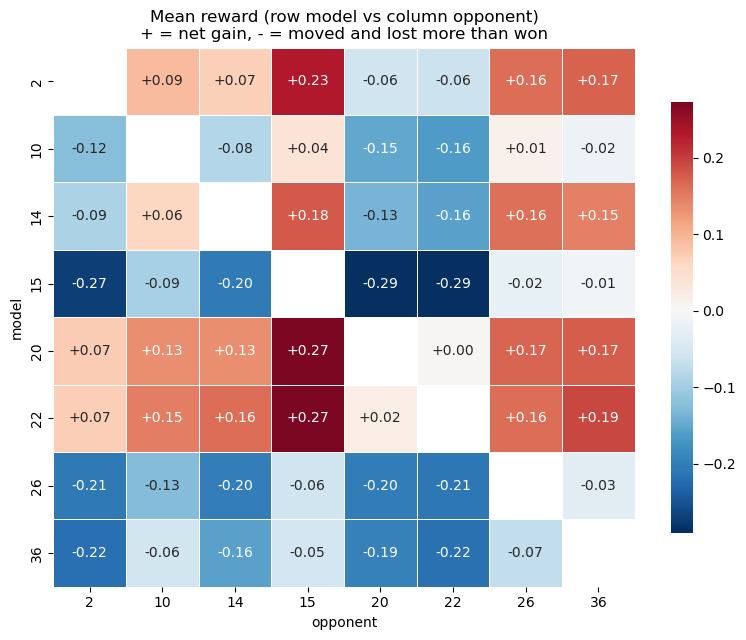

In [5]:
h2h = selfless.groupby(['focus', 'opp']).agg(reward=('f_reward', 'mean'),
                                             score=('f_score', 'mean')).reset_index()
reward_mat = h2h.pivot(index='focus', columns='opp', values='reward').reindex(index=MODELS, columns=MODELS)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(reward_mat, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'shrink': 0.8}, linewidths=0.5, linecolor='white')
ax.set_title('Mean reward (row model vs column opponent)\n+ = net gain, - = moved and lost more than won')
ax.set_xlabel('opponent'); ax.set_ylabel('model'); plt.tight_layout(); plt.show()

## Overall ranking by reward

Each model's mean reward across all opponents (self excluded), with mean score, win rate and Bradley-Terry strength alongside for context. Reward is the net-efficiency headline; the others show how much of it is winning vs cost.

Overall ranking by mean reward:
 rank  model     strategy  mean_reward  mean_score  win_rate  bt_strength
    1     22      central        0.147       0.596     0.653        1.624
    2     20      central        0.138       0.586     0.638        1.532
    3      2      central        0.087       0.537     0.602        1.335
    4     14 intermediate        0.024       0.478     0.519        0.982
    5     10 intermediate       -0.070       0.383     0.453        0.771
    6     36   peripheral       -0.138       0.313     0.391        0.614
    7     26   peripheral       -0.148       0.303     0.400        0.634
    8     15   peripheral       -0.169       0.288     0.342        0.507


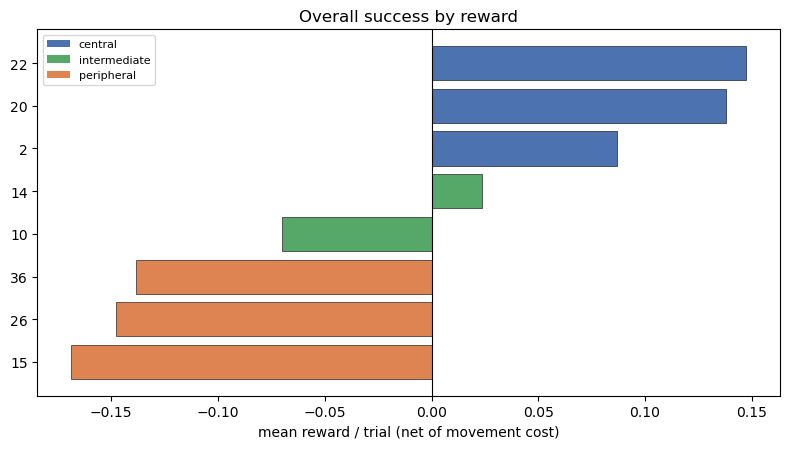

In [6]:
overall = selfless.groupby('focus').agg(
    mean_reward=('f_reward', 'mean'),
    mean_score=('f_score', 'mean'),
    win_rate=('f_win', 'mean')).reset_index().rename(columns={'focus': 'model'})

wins_df = selfless[selfless.f_win == 1].groupby(['focus', 'opp']).size().reset_index(name='w')
wins_mat = wins_df.pivot(index='focus', columns='opp', values='w').reindex(
    index=MODELS, columns=MODELS).fillna(0).to_numpy()
bt = fit_bradley_terry(wins_mat)
overall['bt_strength'] = overall['model'].map(dict(zip(MODELS, bt)))
overall['strategy'] = overall['model'].map(STRATEGY)
overall = overall.sort_values('mean_reward', ascending=False).reset_index(drop=True)
overall['rank'] = np.arange(1, len(overall) + 1)
print("Overall ranking by mean reward:")
print(overall[['rank', 'model', 'strategy', 'mean_reward', 'mean_score', 'win_rate', 'bt_strength']].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.6))
order = overall.sort_values('mean_reward')
ax.barh(np.arange(len(order)), order['mean_reward'],
        color=[STRAT_PALETTE[s] for s in order['strategy']], edgecolor='black', linewidth=0.4)
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(np.arange(len(order))); ax.set_yticklabels(order['model'])
ax.set_xlabel('mean reward / trial (net of movement cost)'); ax.set_title('Overall success by reward')
ax.legend(handles=[Patch(facecolor=STRAT_PALETTE[s], label=s) for s in STRAT_ORDER], fontsize=8)
plt.tight_layout(); plt.show()

## Score vs reward — does efficiency reorder the models?

The key comparison. Score credits winning; reward credits winning *cheaply*. If peripheral models' lower movement cost matters, they should climb the ranking under reward (and central models, which move most, should drop).

Score vs reward (rank_shift > 0 = model climbs when judged on reward):
 model     strategy  mean_score  score_rank  mean_reward  reward_rank  rank_shift  cost
    22      central       0.596           1        0.147            1           0 0.448
    20      central       0.586           2        0.138            2           0 0.448
     2      central       0.537           3        0.087            3           0 0.450
    14 intermediate       0.478           4        0.024            4           0 0.454
    10 intermediate       0.383           5       -0.070            5           0 0.453
    36   peripheral       0.313           6       -0.138            6           0 0.451
    26   peripheral       0.303           7       -0.148            7           0 0.450
    15   peripheral       0.288           8       -0.169            8           0 0.457


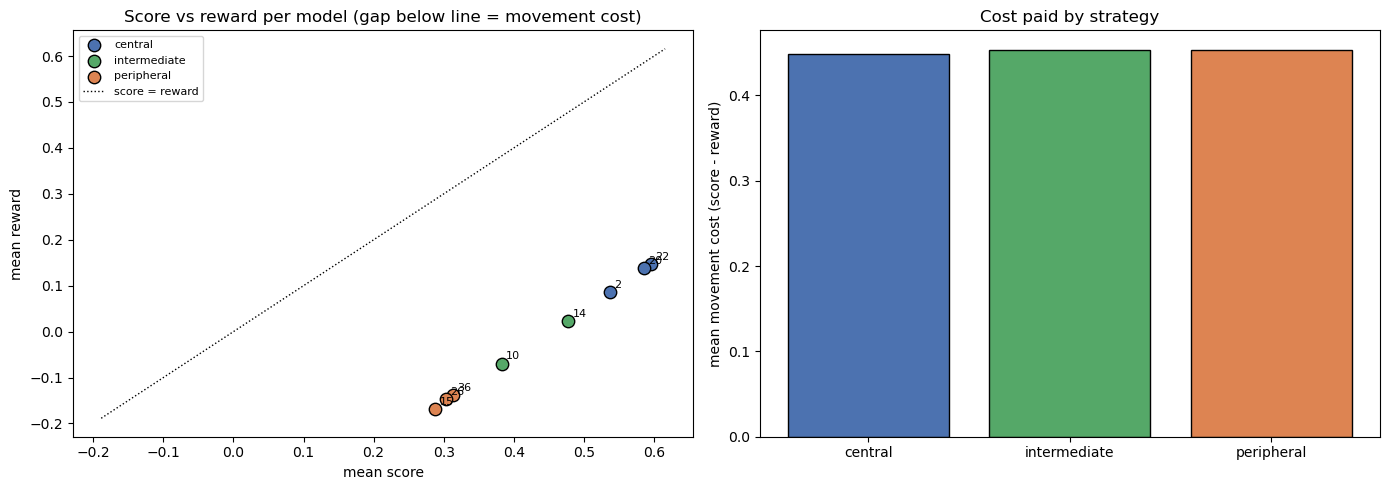

In [7]:
cmp = overall[['model', 'strategy', 'mean_score', 'mean_reward']].copy()
cmp['score_rank'] = cmp['mean_score'].rank(ascending=False).astype(int)
cmp['reward_rank'] = cmp['mean_reward'].rank(ascending=False).astype(int)
cmp['rank_shift'] = cmp['score_rank'] - cmp['reward_rank']   # + = climbs under reward
cmp['cost'] = cmp['mean_score'] - cmp['mean_reward']          # movement cost paid (score minus reward)
print("Score vs reward (rank_shift > 0 = model climbs when judged on reward):")
print(cmp.sort_values('reward_rank')[['model', 'strategy', 'mean_score', 'score_rank',
      'mean_reward', 'reward_rank', 'rank_shift', 'cost']].round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in STRAT_ORDER:
    sub = cmp[cmp.strategy == s]
    axes[0].scatter(sub['mean_score'], sub['mean_reward'], s=80, color=STRAT_PALETTE[s],
                    edgecolor='black', label=s)
for _, r in cmp.iterrows():
    axes[0].annotate(int(r['model']), (r['mean_score'], r['mean_reward']), fontsize=8,
                     xytext=(3, 3), textcoords='offset points')
lims = [min(cmp.mean_reward.min(), cmp.mean_score.min()) - 0.02, cmp.mean_score.max() + 0.02]
axes[0].plot(lims, lims, 'k:', lw=1, label='score = reward')
axes[0].set_xlabel('mean score'); axes[0].set_ylabel('mean reward')
axes[0].set_title('Score vs reward per model (gap below line = movement cost)'); axes[0].legend(fontsize=8)

# movement cost by strategy
cost_by = cmp.groupby('strategy')['cost'].mean().reindex(STRAT_ORDER)
axes[1].bar(range(len(cost_by)), cost_by, color=[STRAT_PALETTE[s] for s in cost_by.index],
            edgecolor='black')
axes[1].set_xticks(range(len(cost_by))); axes[1].set_xticklabels(cost_by.index)
axes[1].set_ylabel('mean movement cost (score - reward)'); axes[1].set_title('Cost paid by strategy')
plt.tight_layout(); plt.show()

## Reading the results

- **Reward ranking = score ranking, exactly** (rank_shift 0 for all 8 models). The per-trial cost (score - reward) is ~0.45 for every model - a constant, because this build penalises every step and episodes are ~fixed length and symmetric between the two competitors.
- So on the tournament data, reward adds nothing over score, and it does **not** measure resting efficiency - this build penalises resting (break absent), the opposite of the training build.
- **To study the reward landscape the models were trained under** (break present, resting free), analyse the **characterisation** data (`model_characterisation_demo`), whose inference used the break-present training build. The tournament, run with a break-absent build, is the wrong tool for that question.
- Wins (who reaches a wall first) are identical to the score notebook, so win-rate and Bradley-Terry are unchanged.